# Instructions
- Make a copy of this notebook in your drive.
- Load the **Netflix Movies and TV Shows dataset**.
- Read through each step and run the cells in order.
- Do not skip steps; each one builds on the previous one.
- Add your own observations wherever possible, especially when exploring graphs.
- This is practice for real-world data preprocessing and EDA, so think about *why* each step is done, not just *how*.
- At the end, feel free to explore further and add more plots, groupbys, or questions of your own.

Welcome to this checkpoint task.

Today we are exploring the Netflix Movies and TV Shows dataset to practice data preprocessing and exploratory data analysis (EDA). Think of the dataset as a big streaming catalogue that needs sorting before it is ready to be recommended to viewers - we will clean it, organize it, and look for patterns worth noticing.

We will be using pandas, numpy, matplotlib, and seaborn for this task.

Run the following cell to import them.

In [1]:
##Importing all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Setting the Scene

Before analyzing anything, we need to bring the dataset into our workspace.

**Your task:**
- Load the dataset into a pandas DataFrame.
- Look at the first few rows to see what the data contains.
- Check the shape of the dataset - how many titles and how many columns are we working with?

Think of this as opening the catalogue for the first time and getting a feel for its size.

In [2]:
##Loading the dataset.
df=pd.read_csv('netflix_titles.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
##The dataset has 8807 rows and 12 columns
df.shape

(8807, 12)

In [5]:
#List of all columns
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

### Level 1: Know Your Columns

Every dataset has its own structure - some columns hold text, some hold numbers, and some may be incomplete.

**Your task:**
- Get a quick overview of column types and how many missing values each column has.
- Double-check that each column's data type makes sense for what it represents.

This is like reading the label on each shelf before you start organizing it.

In [6]:
#Checking for Duplicated Rows if any
print("Duplicated Rows:",df.duplicated().sum())

Duplicated Rows: 0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Level 2: Quick Stats Check

Before diving deeper, it helps to see a summary of the numerical columns.

**Your task:**
- Get summary statistics for the numerical columns.
- Note things like the earliest and most recent release years, and how the values are spread out.

This step gives you a first impression of the range and scale of the data.

In [8]:
##summary statistics for the numerical columns.
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
earliest=df['release_year'].min()
latest=df['release_year'].max()
print("Earliest Release Year:",earliest)
print("Latest Release Year:",latest)

Earliest Release Year: 1925
Latest Release Year: 2021


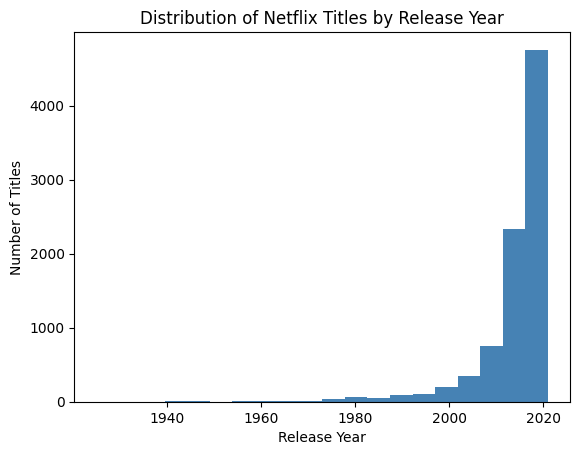

In [10]:
#Histogram for release years. It shows how the values are spread out
plt.hist(df['release_year'], bins=20, color='steelblue')
plt.title('Distribution of Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

**Observation**:

The histogram shows that the Netflix dataset is dominated by recent titles, peaking between 2018 and 2020. The platform appears to favor newer content over a balanced mix of older and newer titles.

## Level 3: Clean the Catalogue (Missing Values)

Some entries in a streaming catalogue are incomplete, and we need to decide how to handle that.

**Your tasks:**
- Check how many missing values are in each column.
- For this dataset, handle missing values in **`director`** and **`country`** by removing those rows.
- Re-check to confirm there are no missing values left in those two columns.

> Tip: Do a quick sanity check after cleaning - the row count should drop a bit.

In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


### **Observation**:-
 The Director, Country, and Cast columns contain the highest number of missing values. The  Date Added and Duration columns also have a few missing values.

In [12]:
df=df.dropna(subset=['director','country'])

In [13]:
df.shape

(5751, 12)

# **Observation**:-
Rows before dropping null values:8807. Rows aftr dropping null values:5751. Total no. of columns dropped:3056
                 

In [14]:
##Cross Checking if still null values exist
df[['director','country']].isnull().sum()

,0
director,0
country,0


## Level 4: Fix the `date_added` Column (Data Types)

The `date_added` column is usually stored as plain text, which makes it hard to work with dates properly.

**Your tasks:**
- Convert **`date_added`** to a proper datetime type.
- Create a new column called **`year_added`** that extracts just the year from `date_added`.
- Run a quick `info()` check to confirm the changes.

> If the conversion produces errors, check for stray spaces or unexpected formats in the column first.

In [15]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year


# Confirm the dtype changes went through
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5751 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5751 non-null   object        
 1   type          5751 non-null   object        
 2   title         5751 non-null   object        
 3   director      5751 non-null   object        
 4   cast          5336 non-null   object        
 5   country       5751 non-null   object        
 6   date_added    5751 non-null   datetime64[ns]
 7   release_year  5751 non-null   int64         
 8   rating        5750 non-null   object        
 9   duration      5748 non-null   object        
 10  listed_in     5751 non-null   object        
 11  description   5751 non-null   object        
 12  year_added    5751 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(10)
memory usage: 606.6+ KB


## Level 5: The Longest Watches

Some titles run much longer than others. Let's find the standouts.

**Your task:**
- List the **Top 5 longest movies** in the dataset.
- Display their **title, country, release_year, and duration**.

Think of this as building a short list for viewers who want an epic movie night.

## Level 6: Movies vs TV Shows

The catalogue contains two kinds of content: movies and TV shows.

**Your task:**
- Count how many titles fall into each `type` category.
- Create a bar chart to visualize the counts.
- Answer: which type makes up the larger share of the catalogue?

In [16]:
type_counts = df['type'].value_counts()
type_counts

,count
type,
Movie,5562
TV Show,189


Text(0, 0.5, 'Number of Titles')

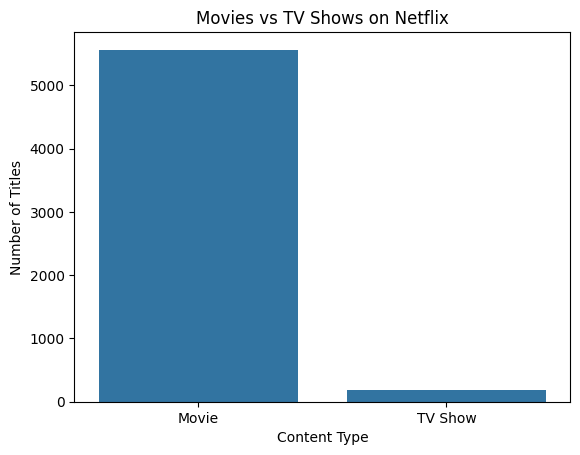

In [17]:
sns.barplot(x=type_counts.index, y=type_counts.values)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")


# **Observation:-**
Movies significantly outnumber TV shows in the dataset, highlighting Netflix's stronger focus on movie content in this catalogue.

## Level 7: Where Does the Content Come From?

Netflix sources content from many countries.

**Your task:**
- Find the **Top 5 countries** with the highest number of titles.
- Show their contribution using a pie chart.

This will help us see which countries dominate the catalogue.

In [18]:
country_split = df['country'].str.split(', ').explode()
top5_countries = country_split.value_counts().head(5)
print(top5_countries)


country
United States     2749
India              961
United Kingdom     537
Canada             317
France             311
Name: count, dtype: int64


Text(0.5, 1.0, 'Top 5 Countries by Number of Netflix Titles')

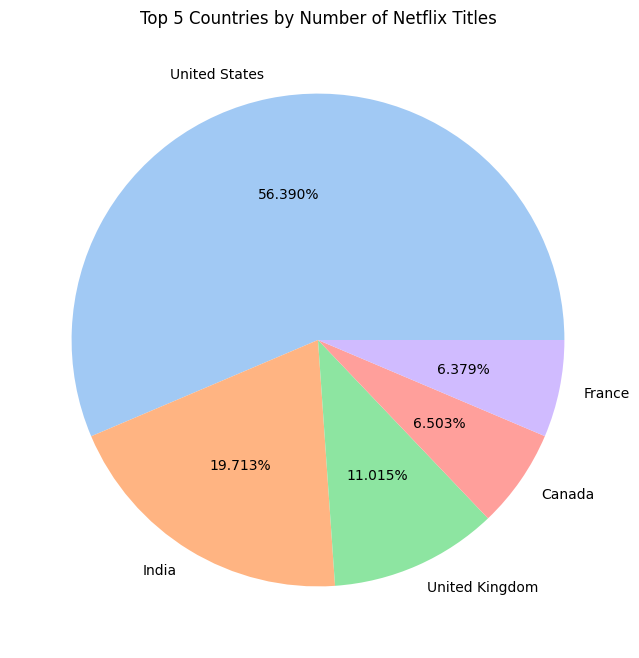

In [19]:
##Pie Chart
plt.figure(figsize=(8,8))
plt.pie(top5_countries.values, labels=top5_countries.index, autopct='%1.3f%%',colors=sns.color_palette('pastel'))

plt.title('Top 5 Countries by Number of Netflix Titles')


# **Observation:-**
The United States dominates the Netflix dataset, contributing over half of all titles (56%), while India ranks a distant second (20%). Together, the top five countries account for the majority of the dataset.

## Level 8: Genre Leaders by Country

Different genres may be led by different countries.

**Your task:**
- For each genre in `listed_in`, find the **country** that has produced the most titles in that genre.
- Print the results as a list (Genre -> Leading Country).

> Note: a title can belong to more than one genre - think about how you want to handle that before grouping.

In [20]:
genre_country = df[['listed_in', 'country']].copy()
genre_country['listed_in'] = genre_country['listed_in'].str.split(', ')
genre_country = genre_country.explode('listed_in')
genre_country['country'] = genre_country['country'].str.split(', ')
genre_country = genre_country.explode('country')
genre_country_counts = (genre_country.groupby(['listed_in', 'country']).size().reset_index(name='count'))
genre_leaders = (genre_country_counts.sort_values('count', ascending=False).drop_duplicates('listed_in'))

for _, row in genre_leaders.iterrows():
    print(f"{row['listed_in']} -> {row['country']}")



International Movies -> India
Dramas -> United States
Comedies -> United States
Documentaries -> United States
Action & Adventure -> United States
Independent Movies -> United States
Children & Family Movies -> United States
Thrillers -> United States
Romantic Movies -> United States
Stand-Up Comedy -> United States
Horror Movies -> United States
Sci-Fi & Fantasy -> United States
Music & Musicals -> United States
Sports Movies -> United States
Classic Movies -> United States
Anime Features -> Japan
LGBTQ Movies -> United States
Cult Movies -> United States
Faith & Spirituality -> United States
Docuseries -> United States
Crime TV Shows -> United States
British TV Shows -> United Kingdom
Movies -> United States
International TV Shows -> Spain
TV Comedies -> United States
Korean TV Shows -> South Korea
TV Dramas -> United States
TV Action & Adventure -> United States
Anime Series -> Japan
Stand-Up Comedy & Talk Shows -> United States
Spanish-Language TV Shows -> Spain
Romantic TV Shows -

# **Observation:-**:-
The United States leads in most Western genres (Action & Adventure, Comedies, Classic Movies), while India and Japan take the lead in region-specific genres. A trend we might identify is that genres are strongly tied to where more content is produced

# **Approach:-**
Multiple genres and countries were handled by splitting and exploding the listed_in and country columns, creating one genre–country pair per row. The data was then grouped to count titles, sorted by count, and the leading country for each genre was selected.

## Level 9: Netflix's Busiest Year

Netflix has grown its catalogue steadily over the years, but some years stand out more than others.

**Your task:**
- Group the data by `year_added`.
- Find the year in which Netflix added the **most titles** to its catalogue.

This shows us the point where the platform's library grew the fastest.

Netflix added the most titles in 2019, with 1352 titles.


Text(0, 0.5, 'Number of Titles')

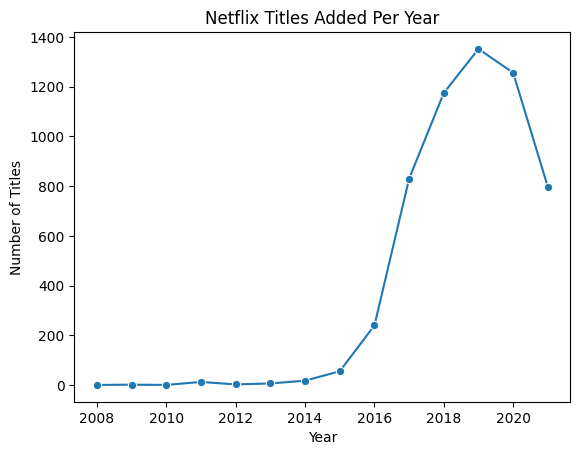

In [21]:
titles_per_year = df['year_added'].value_counts().sort_index()
busiest_year = titles_per_year.idxmax()
print(f"Netflix added the most titles in {busiest_year}, with {titles_per_year.max()} titles.")

# Plotting the trend observation
sns.lineplot(x=titles_per_year.index, y=titles_per_year.values, marker='o')
plt.title("Netflix Titles Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")



# **Observation:-**
Netflix's catalogue grew rapidly until 2019, after which title additions declined slightly. This slowdown may have been influenced by the COVID-19 pandemic, which disrupted content production and releases globally.

## Final Task: Open Exploration

You have worked through each step above - now it's time to explore on your own.

**Your final task:**
- Choose any 2 to 3 plots of your own choice that reveal an interesting pattern in the data.

This is your creative zone - treat it as building your own short story from the dataset. When you are done, share your best plot and the observation behind it with the group.

Text(0, 0.5, 'Number of Movies')

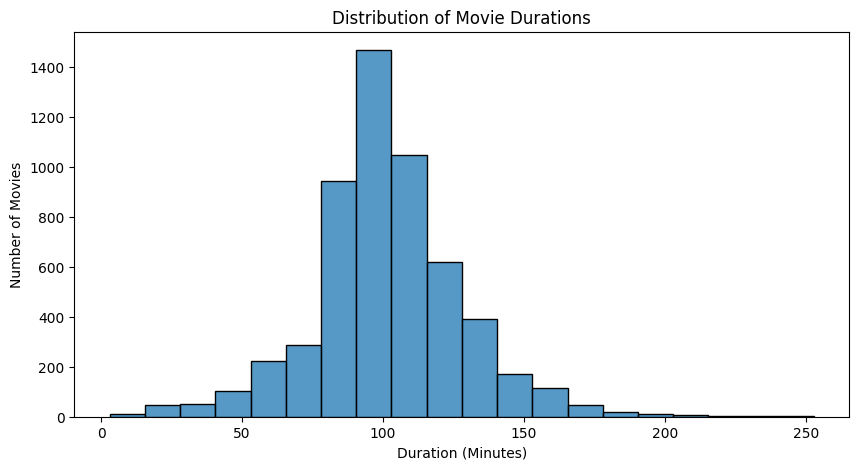

In [24]:
movies = df[df['type'] == 'Movie'].copy()
# Remove missing durations
movies = movies.dropna(subset=['duration'])
movies['duration_mins'] = (movies['duration'].str.replace(' min', '', regex=False).astype(float))

# Plot
plt.figure(figsize=(10,5))
sns.histplot(movies['duration_mins'], bins=20)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")


# **Observation**
Most movies have durations around 90–100 minutes, with a few longer movies creating a right-skewed distribution.

/tmp/ipykernel_29424/995821049.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.values, y=rating_counts.index,palette='pastel')


Text(0, 0.5, 'Rating')

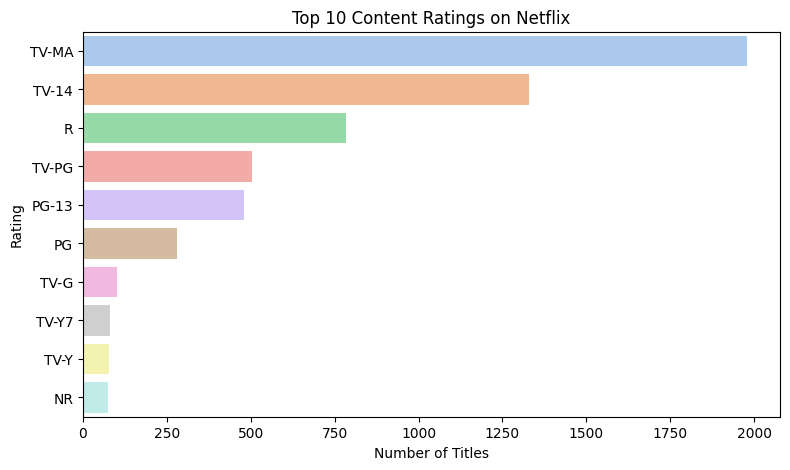

In [26]:
plt.figure(figsize=(9, 5))
rating_counts = df['rating'].value_counts().head(10)
sns.barplot(x=rating_counts.values, y=rating_counts.index,palette='pastel')
plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')


# **Ratings:**
TV-MA and TV-14 dominate the rating distribution, confirming Netflix's catalogue skews toward mature/teen audiences rather than young children.

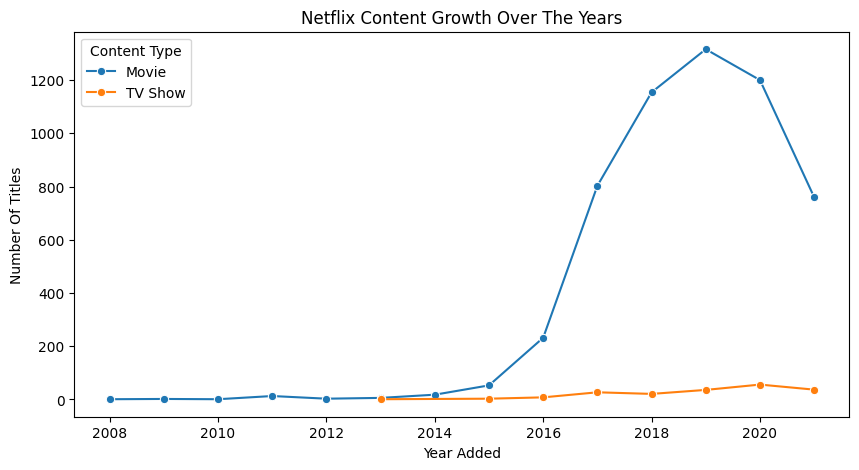

In [34]:
content_growth = df.groupby(['year_added', 'type']).size().reset_index(name='Titles')
plt.figure(figsize=(10, 5))
sns.lineplot(data=content_growth,x='year_added',y='Titles',hue='type',marker='o')
plt.title("Netflix Content Growth Over The Years")
plt.xlabel("Year Added")
plt.ylabel("Number Of Titles")
plt.legend(title="Content Type")


# **Observation:-**
Netflix's catalogue expanded rapidly after the mid-2010s, with movies consistently making up the larger share of additions. TV show additions also increased over time, showing Netflix's growing focus on original series and diverse content formats.

Text(0, 0.5, 'Number of Titles')

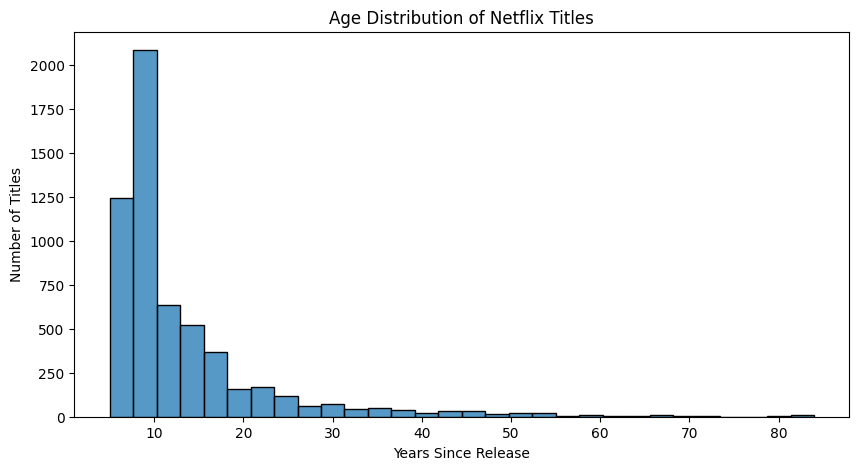

In [30]:
df['content_age'] = 2026 - df['release_year']
plt.figure(figsize=(10,5))
sns.histplot(df['content_age'], bins=30)
plt.title("Age Distribution of Netflix Titles")
plt.xlabel("Years Since Release")
plt.ylabel("Number of Titles")

# **Observation:-**
Netflix's catalogue is heavily focused on recent content, with most titles released within the last 10 years. Older titles are much less common, creating a long tail of classic and older content